In [3]:
!pip install librosa scipy matplotlib numpy --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Задание 1

- Загрузим два временных ряда `ts_alpha` и `ts_beta` с помощью приведённого кода.

In [4]:
import requests
from io import BytesIO
import numpy as np

resp = requests.get("https://zenodo.org/records/10897398/files/stationarity_ts1.npy?download=1")
resp.raise_for_status()
ts_alpha = np.load(BytesIO(resp.content))
print(len(ts_alpha))

resp = requests.get("https://zenodo.org/records/10897398/files/stationarity_ts2.npy?download=1")
resp.raise_for_status()
ts_beta = np.load(BytesIO(resp.content))
print(len(ts_beta))

100
100


1. Построим графики обоих временных рядов.
2. Оценим визуально, является ли каждый ряд стационарным.

# ---------------------------------------------------------

In [5]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

np.random.seed(42)

from io import BytesIO
import requests

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [11, 7]
plt.rcParams['figure.dpi'] = 100

### Часть 1

In [6]:
resp = requests.get("https://zenodo.org/records/10897398/files/stationarity_ts1.npy?download=1")
resp.raise_for_status()
ts_alpha = np.load(BytesIO(resp.content))
print(len(ts_alpha))

resp = requests.get("https://zenodo.org/records/10897398/files/stationarity_ts2.npy?download=1")
resp.raise_for_status()
ts_beta = np.load(BytesIO(resp.content))
print(len(ts_beta))

100
100


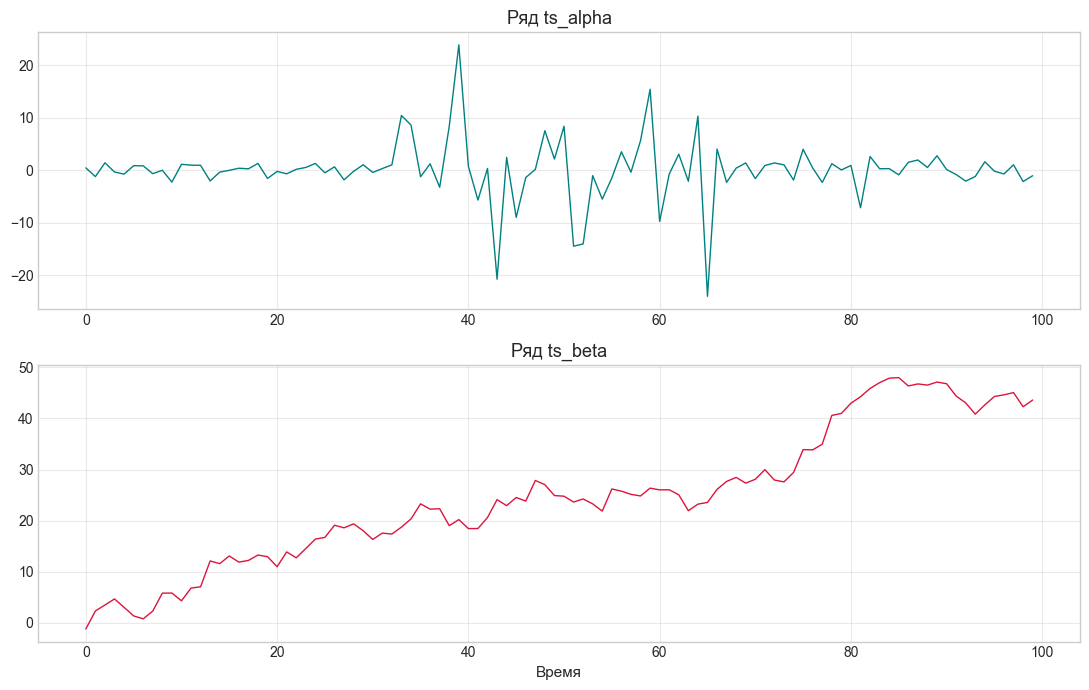

In [7]:
idx = np.arange(len(ts_alpha))

fig, axes = plt.subplots(2, 1, figsize=(11, 7))

axes[0].plot(idx, ts_alpha, color='teal', linewidth=1.0)
axes[0].set_title('Ряд ts_alpha', fontsize=13)
axes[0].grid(True, alpha=0.4)

axes[1].plot(idx, ts_beta, color='crimson', linewidth=1.0)
axes[1].set_title('Ряд ts_beta', fontsize=13)
axes[1].set_xlabel('Время', fontsize=11)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

На первом графике видны резкие выбросы в районе 40-65. Дисперсия непостоянна. Ряд нестационарен.

На втором графике заметен восходящий тренд. Среднее и дисперсия растут. Ряд нестационарен.

### Часть 2

СТАТИСТИКА ПО УЧАСТКАМ

In [8]:
parts_a = np.array_split(ts_alpha, 10)
parts_b = np.array_split(ts_beta, 10)

print("ts_alpha:")
for i, part in enumerate(parts_a, 1):
    print(f"  участок {i}: среднее={np.mean(part):.2f}, дисперсия={np.var(part):.2f}")

print("\nts_beta:")
for i, part in enumerate(parts_b, 1):
    print(f"  участок {i}: среднее={np.mean(part):.2f}, дисперсия={np.var(part):.2f}")

ts_alpha:
  участок 1: среднее=-0.14, дисперсия=1.11
  участок 2: среднее=0.12, дисперсия=1.17
  участок 3: среднее=0.05, дисперсия=0.77
  участок 4: среднее=4.92, дисперсия=59.92
  участок 5: среднее=-2.33, дисперсия=55.95
  участок 6: среднее=-0.37, дисперсия=79.17
  участок 7: среднее=-1.95, дисперсия=77.82
  участок 8: среднее=0.35, дисперсия=3.19
  участок 9: среднее=0.30, дисперсия=7.29
  участок 10: среднее=-0.52, дисперсия=1.35

ts_beta:
  участок 1: среднее=2.82, дисперсия=4.50
  участок 2: среднее=10.51, дисперсия=9.30
  участок 3: среднее=16.02, дисперсия=7.52
  участок 4: среднее=19.73, дисперсия=4.98
  участок 5: среднее=23.27, дисперсия=9.43
  участок 6: среднее=24.61, дисперсия=1.77
  участок 7: среднее=25.54, дисперсия=3.96
  участок 8: среднее=32.74, дисперсия=22.71
  участок 9: среднее=46.29, дисперсия=2.22
  участок 10: среднее=43.77, дисперсия=2.48


В ts_alpha заметны резкие скачки среднего и дисперсии на участках 4-7. Это подтверждает нестационарность.

В ts_beta среднее монотонно растёт от 2.8 до 43.8. Это типичное случайное блуждание с трендом.

ГИСТОГРАММЫ

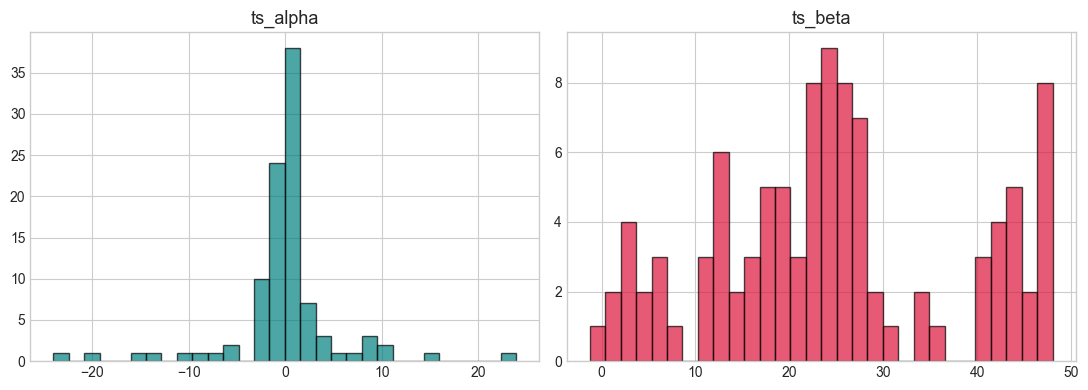

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(ts_alpha, bins=30, color='teal', alpha=0.7, edgecolor='black')
axes[0].set_title('ts_alpha', fontsize=13)
axes[1].hist(ts_beta, bins=30, color='crimson', alpha=0.7, edgecolor='black')
axes[1].set_title('ts_beta', fontsize=13)
plt.tight_layout()
plt.show()

ts_alpha имеет выраженный тяжёлый хвост. Основная масса значений сосредоточена около нуля.

ts_beta показывает плоское широкое распределение без выраженного центра. Это характерно для рядов с трендом.

ТЕСТ ДИКИ-ФУЛЛЕРА

In [10]:
adf_a, p_a, _, _, _, _ = adfuller(ts_alpha)
print(f"\nts_alpha: ADF={adf_a:.4f}, p-value={p_a:.4f}")

adf_b, p_b, _, _, _, _ = adfuller(ts_beta)
print(f"ts_beta: ADF={adf_b:.4f}, p-value={p_b:.4f}")


ts_alpha: ADF=-3.0324, p-value=0.0320
ts_beta: ADF=-1.3223, p-value=0.6189


ts_alpha: p-value = 0.032 < 0.05. Статистический тест подтверждает стационарность.

ts_beta: p-value = 0.619 > 0.05. Ряд нестационарен.

### Часть 3

Декомпозиция ts_alpha

In [11]:
dec = seasonal_decompose(ts_alpha, model='additive', period=12)
resid = dec.resid[~np.isnan(dec.resid)]

adf_r, p_r, _, _, _, _ = adfuller(resid)
print(f"ts_alpha остатки: p-value={p_r:.6f}")

ts_alpha остатки: p-value=0.000695


Дифференцирование ts_beta

In [12]:
ts_beta_diff = np.diff(ts_beta)

adf_d, p_d, _, _, _, _ = adfuller(ts_beta_diff)
print(f"ts_beta разность: p-value={p_d:.6f}")

ts_beta разность: p-value=0.000000


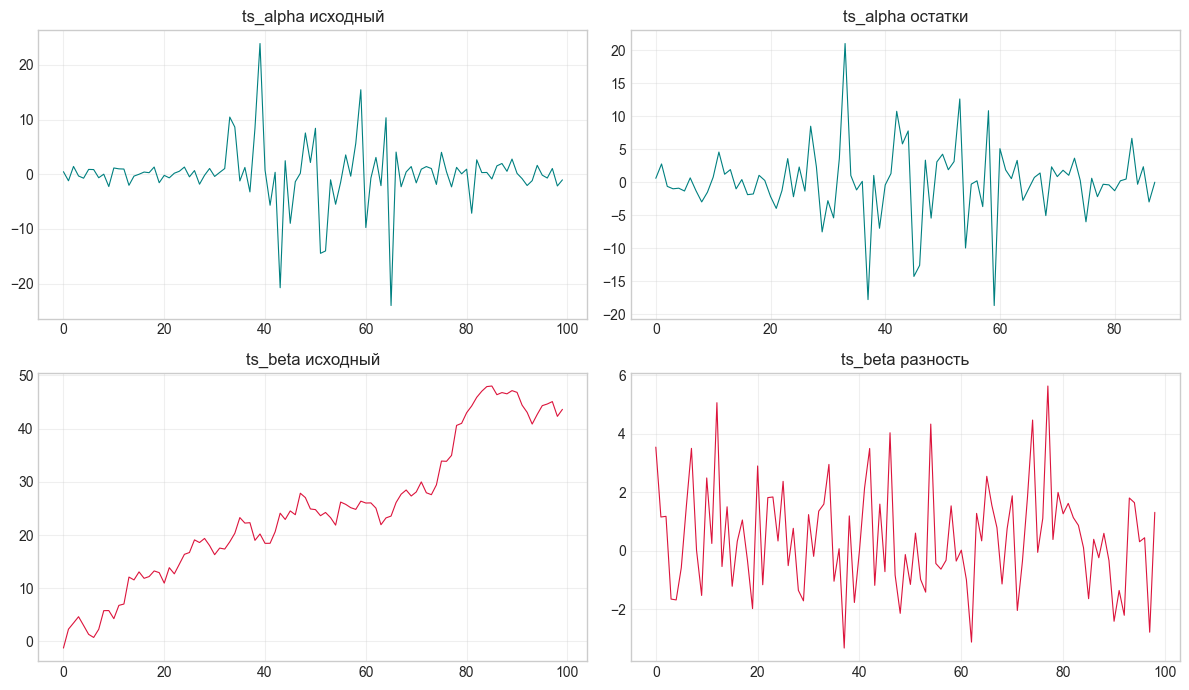

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

axes[0, 0].plot(ts_alpha, color='teal', linewidth=0.8)
axes[0, 0].set_title('ts_alpha исходный')
axes[0, 1].plot(resid, color='teal', linewidth=0.8)
axes[0, 1].set_title('ts_alpha остатки')

axes[1, 0].plot(ts_beta, color='crimson', linewidth=0.8)
axes[1, 0].set_title('ts_beta исходный')
axes[1, 1].plot(ts_beta_diff, color='crimson', linewidth=0.8)
axes[1, 1].set_title('ts_beta разность')

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

После преобразований оба ряда стали стационарными. Остатки ts_alpha выглядят как белый шум, ts_beta после дифференцирования потерял тренд и стал пригодным для моделирования.